In [1]:
import jax
import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import jax.numpy as jnp
wanted_type_complex = jnp.complex128
wanted_type_real = jnp.float64
print("Devices:", jax.devices())
if not any(d.platform == "gpu" for d in jax.devices()):
    raise RuntimeError("JAX is not using a GPU.")
import sys
import numpy as np
from scipy.sparse.linalg import LinearOperator, eigs
from scipy.special import jv
jax.config.update("jax_enable_x64", True)
import sys
sys.path.insert(0, "/home/tmalasda/dynamiqs")
import dynamiqs as dq
dq.set_precision("double")
assert (
    dq.__file__ == "/home/tmalasda/dynamiqs/dynamiqs/__init__.py"
), "Unexpected dynamiqs install; check sys.path."
import matplotlib.pyplot as plt
import json

Devices: [CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3)]


In [2]:
n_a = 13
n_b = 6
cheb_degree = 6
m_arnoldi_0 = 60
m_arnoldi = 120
margin = 1e-2
alpha_sq = 5

def build_ats_hamiltonian(
    n_a=20,
    n_b=11,
    alpha_sq=8.5,
    w_a=25.338776456203686,
    kappa_b=5 / 10.4,
    E_J=37 * 2 * np.pi,
    phi_a=0.11,
    phi_b=0.204,
    epsilon_p=0.1,
    n_periods=1,
):
    """Build the driven full-ATS Lindbladian in the lab frame.

    Returns
    -------
    Ham : dynamiqs time-dependent operator.
    jump_ops : list
        Lindblad jump operators ``[sqrt(kappa_1) a, sqrt(kappa_b) b]``.
    T_block : float
        Duration of one Floquet block, ``n_periods * 2*pi / w_a``.
    params : dict
        Derived quantities (``g``, ``g2``, ``kappa_1``, ``kappa_2``,
        ``epsilon_d``, ``w_b``, ``T_drive``) for reference.
    """
    w_b = 2 * w_a

    # couplings derived from the pump
    g = np.sin(epsilon_p) * E_J * phi_a**2 * phi_b
    g2 = jv(1, epsilon_p) * E_J * phi_a**2 * phi_b

    kappa_2 = 4 * g**2 / kappa_b
    kappa_1 = 0.005 * kappa_2

    epsilon_d = 2 * alpha_sq * g2

    # Operators
    a = dq.destroy(n_a)
    b = dq.destroy(n_b)
    Ia = dq.eye(n_a)
    Ib = dq.eye(n_b)

    a_tot = dq.tensor(a, Ib)
    b_tot = dq.tensor(Ia, b)

    

    phi_a_tot = phi_a*(a_tot + dq.dag(a_tot))
    phi_b_tot = phi_b*(b_tot + dq.dag(b_tot))

    non_linear_op = dq.sinm(phi_a_tot + phi_b_tot) - phi_a_tot - phi_b_tot

    H_drive = dq.modulated(
        lambda t: epsilon_d * jnp.cos(w_b*t),
        b_tot + dq.dag(b_tot)
        )

    H_0 = w_a*a_tot@dq.dag(a_tot) + w_b*b_tot@dq.dag(b_tot)

    Ham = H_0 + H_drive - 2*E_J*jnp.sin(epsilon_p)*non_linear_op 

    jump_ops = [
        jnp.sqrt(kappa_1) * a_tot,
        jnp.sqrt(kappa_b) * b_tot,
    ]

    T_drive = 2 * jnp.pi / w_a
    T_block = n_periods * T_drive

    params = {
        "g": g,
        "g2": g2,
        "kappa_1": kappa_1,
        "kappa_2": kappa_2,
        "kappa_b": kappa_b,
        "epsilon_d": epsilon_d,
        "w_a": w_a,
        "w_b": w_b,
        "T_drive": T_drive,
    }
    return Ham, jump_ops, T_block, params

def build_ats_hamiltonian_r(
    n_a=20,
    n_b=11,
    alpha_sq=8.5,
    w_a=25.338776456203686,
    kappa_b=5 / 10.4,
    E_J=37 * 2 * np.pi,
    phi_a=0.11,
    phi_b=0.204,
    epsilon_p=.3,
    n_periods=1,
):
    """Build the driven full-ATS Lindbladian in the rotating frame.

    Mirrors the operator/Hamiltonian cells of ``Chebyshev-Arnoldi.ipynb``.

    Returns
    -------
    Ham : dynamiqs time-dependent operator
        The rotating-frame Hamiltonian ``Ham_full_r``.
    jump_ops : list
        Lindblad jump operators ``[sqrt(kappa_1) a, sqrt(kappa_b) b]``.
    T_block : float
        Duration of one Floquet block, ``n_periods * 2*pi / w_a``.
    params : dict
        Derived quantities (``g``, ``g2``, ``kappa_1``, ``kappa_2``,
        ``epsilon_d``, ``w_b``, ``T_drive``) for reference.
    """
    w_b = 2 * w_a

    # couplings derived from the pump
    g = np.sin(epsilon_p) * E_J * phi_a**2 * phi_b
    g2 = jv(1, epsilon_p) * E_J * phi_a**2 * phi_b

    kappa_2 = 4 * g**2 / kappa_b
    kappa_1 = 0.005 * kappa_2

    epsilon_d = 2 * alpha_sq * g2

    # Operators
    a = dq.destroy(n_a)
    b = dq.destroy(n_b)
    Ia = dq.eye(n_a)
    Ib = dq.eye(n_b)

    a_tot = dq.tensor(a, Ib)
    b_tot = dq.tensor(Ia, b)

    a_r = dq.modulated(lambda t: jnp.exp(-1j * w_a * t), a_tot)
    a_dag_r = dq.modulated(lambda t: jnp.exp(1j * w_a * t), dq.dag(a_tot))
    b_r = dq.modulated(lambda t: jnp.exp(-1j * w_b * t), b_tot)
    b_dag_r = dq.modulated(lambda t: jnp.exp(1j * w_b * t), dq.dag(b_tot))

    phi_a_tot_r = phi_a * (a_r + a_dag_r)
    phi_b_tot_r = phi_b * (b_r + b_dag_r)

    non_linear_op_r = dq.sinm(phi_a_tot_r + phi_b_tot_r) - phi_a_tot_r - phi_b_tot_r

    H_drive_r = epsilon_d * (b_tot + dq.dag(b_tot)) / 2

    Ham = -2 * E_J * jnp.sin(epsilon_p) * non_linear_op_r + H_drive_r

    jump_ops = [
        jnp.sqrt(kappa_1) * a_tot,
        jnp.sqrt(kappa_b) * b_tot,
    ]

    T_drive = 2 * jnp.pi / w_a
    T_block = n_periods * T_drive

    params = {
        "g": g,
        "g2": g2,
        "kappa_1": kappa_1,
        "kappa_2": kappa_2,
        "kappa_b": kappa_b,
        "epsilon_d": epsilon_d,
        "w_a": w_a,
        "w_b": w_b,
        "T_drive": T_drive,
    }
    return Ham, jump_ops, T_block, params

In [3]:
Ham_full, jump_ops, T_block, params = build_ats_hamiltonian_r(n_a = n_a, n_b = n_b, alpha_sq = alpha_sq, epsilon_p = .1)

/home/tmalasda/venvs/dq_gpu/lib/python3.11/site-packages/equinox/_module/_prebuilt.py:46: UserWarning: A `SparseDIADataArray` has been converted to a `DenseDataArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


In [4]:
tsave = jnp.array([0.0, T_block])

In [5]:
propagator = dq.mepropagator(Ham_full, jump_ops, tsave).propagators[-1].to_jax()

|██████████| 100.0% ◆ elapsed 8.42s ◆ remaining 0.00ms   


In [6]:
eig_val, eig_vec = jnp.linalg.eig(propagator)

In [7]:
idx_sort = jnp.argsort(eig_val)
bit_flip_mu = eig_val[idx_sort[-2]]
bit_flip_vec = eig_vec[:,idx_sort[-2]]
bit_flip_lambda = -jnp.log(bit_flip_mu) / T_block
print(bit_flip_lambda)

(5.294654691527124e-05+1.1464650434910638e-14j)


In [36]:
idx_sort = jnp.argsort(eig_val)
bit_flip_mu = eig_val[idx_sort[-2]]
bit_flip_vec = eig_vec[:,idx_sort[-2]]
bit_flip_lambda = -jnp.log(bit_flip_mu) / T_block
print(bit_flip_lambda)

(0.00011673920585332101-2.778954410384947e-15j)


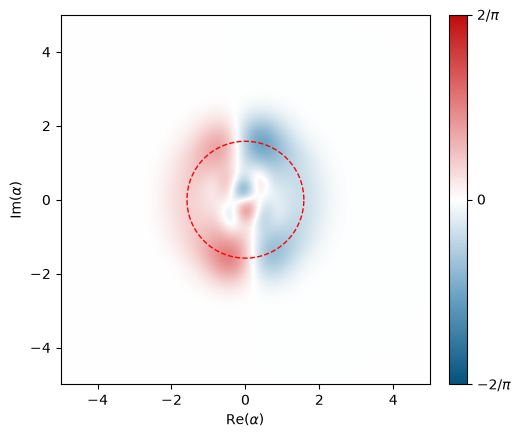

In [48]:
rho_bit_flip = dq.unvectorize(dq.asqarray(bit_flip_vec[:, None]))
rho_bit_flip = dq.asqarray(dq.to_jax(rho_bit_flip), dims=(n_a, n_b))
theta = np.linspace(0,2*np.pi, 100)

fig ,ax = plt.subplots()
dq.plot.wigner(dq.ptrace(rho_bit_flip,0), ax = ax)
ax.plot(np.sqrt(alpha_sq/2) * np.cos(theta), np.sqrt(alpha_sq/2) * np.sin(theta), color='r', 
        linewidth = 1, linestyle = '--')
plt.show()